In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

from src.graphs import StaticGraph, IntersectingEdgesGraph
from src.bwt import HardWeldedTree

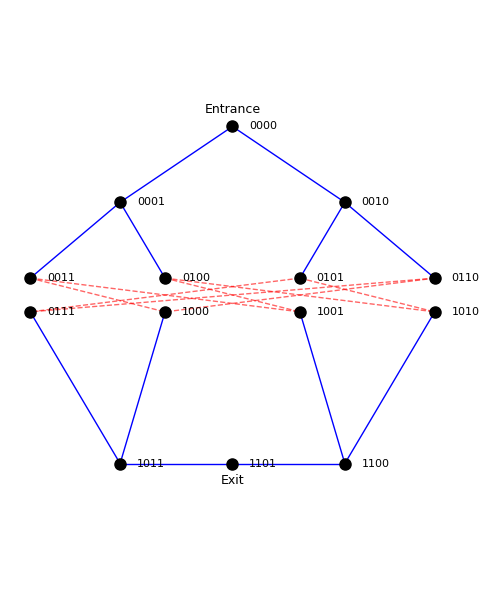

In [2]:
maze = HardWeldedTree(2)
edges = maze.get_edges()
fig = maze.draw()
plt.show()

In [3]:
print("Edges:")
for e in edges:
    print(e[0], '--->', e[1])

Edges:
0000 ---> 0001
0110 ---> 0111
1010 ---> 0100
0101 ---> 1010
0111 ---> 0101
0000 ---> 0010
0110 ---> 1000
0101 ---> 0111
0100 ---> 1010
1001 ---> 1100
0010 ---> 0110
0111 ---> 1011
1010 ---> 0101
1001 ---> 0011
1001 ---> 0100
1000 ---> 0110
1000 ---> 0011
0011 ---> 1000
0010 ---> 0101
0100 ---> 1001
0111 ---> 0110
1000 ---> 1011
1011 ---> 1101
0001 ---> 0011
1100 ---> 1101
0001 ---> 0100
0011 ---> 1001
1010 ---> 1100


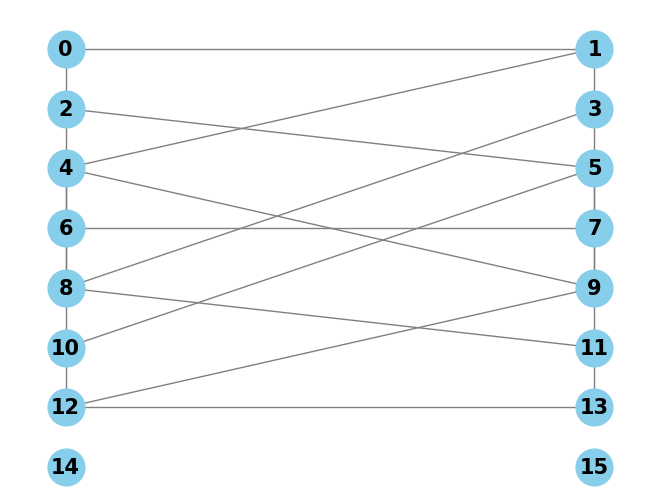

None

In [4]:
# Use your existing graph analysis
G_tree = StaticGraph(edges)
display(G_tree.draw())

Edges: {('0000', '0001'), ('0110', '0111'), ('0010', '0101'), ('1010', '0100'), ('1011', '1101'), ('1000', '0011'), ('1001', '1100')}


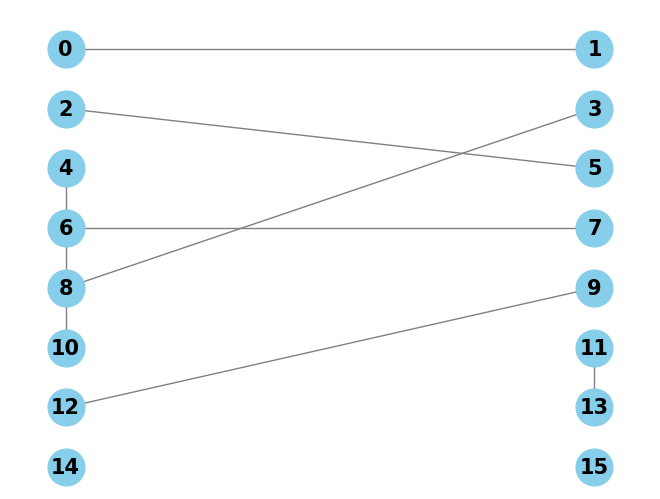

None

Simplified circuit: 


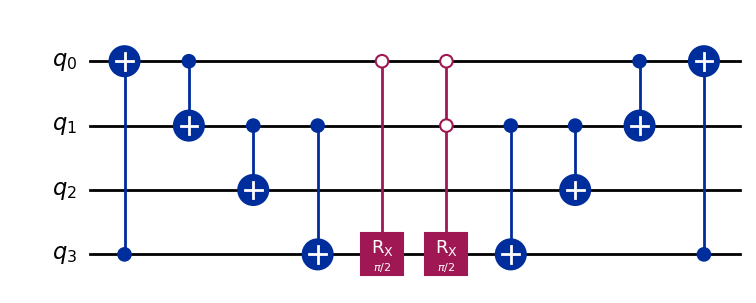

Edges: {('0110', '1000'), ('0111', '0101'), ('0000', '0010'), ('1001', '0011'), ('1100', '1101'), ('0100', '1010')}


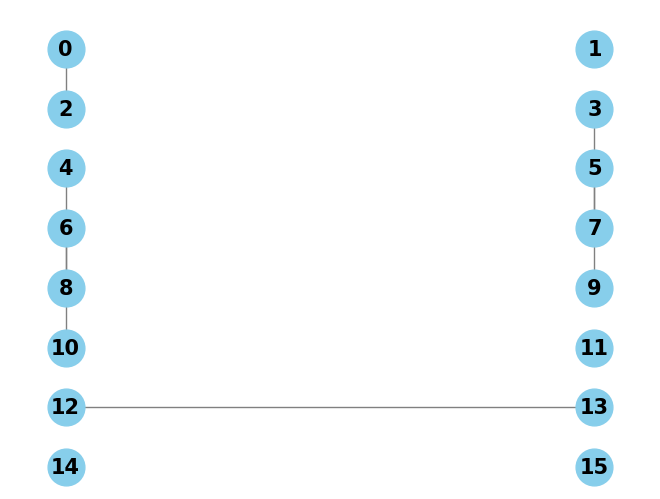

None

Simplified circuit: 


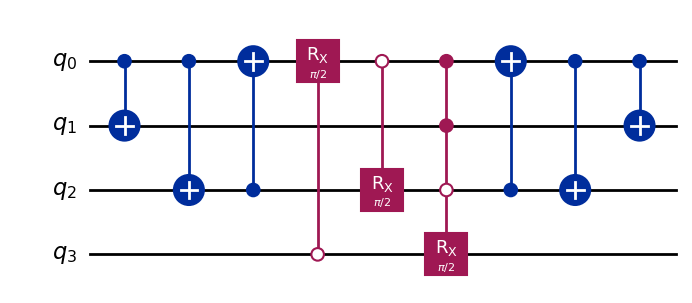

Edges: {('0011', '1000'), ('0010', '0110'), ('0111', '1011'), ('0101', '1010'), ('1001', '0100')}


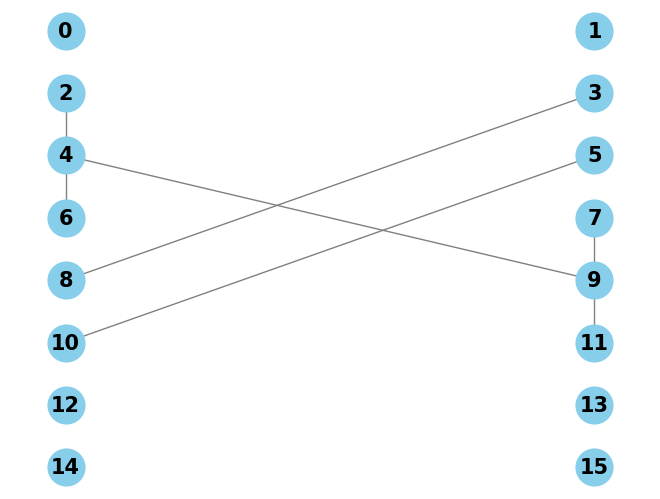

None

Simplified circuit: 


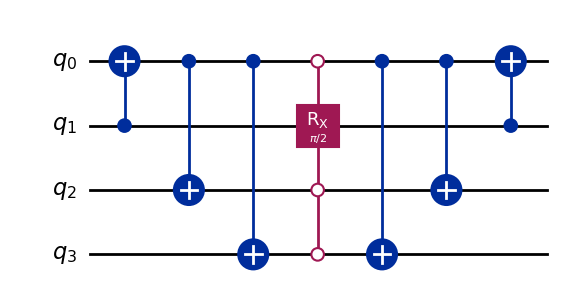

Edges: {('1000', '0110'), ('0001', '0011'), ('0101', '0111'), ('1010', '1100'), ('0100', '1001')}


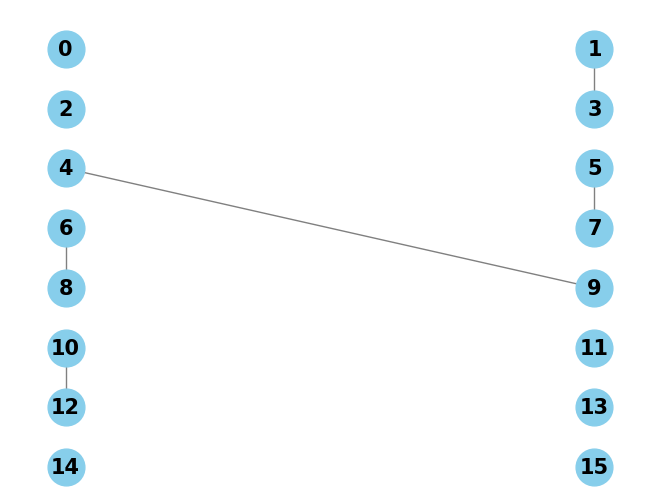

None

Simplified circuit: 


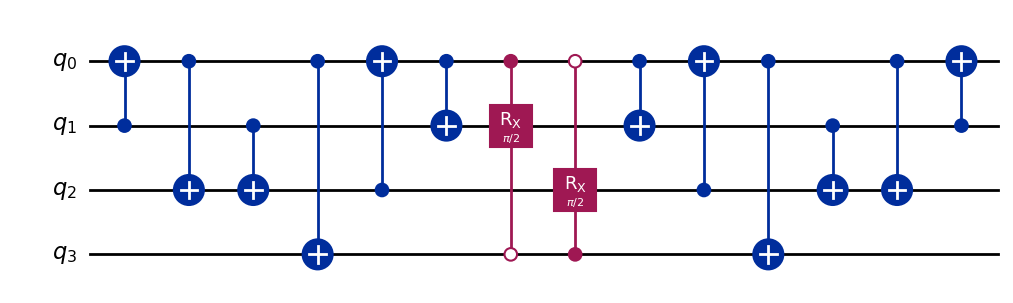

Edges: {('0111', '0110'), ('1010', '0101'), ('1000', '1011'), ('0011', '1001'), ('0001', '0100')}


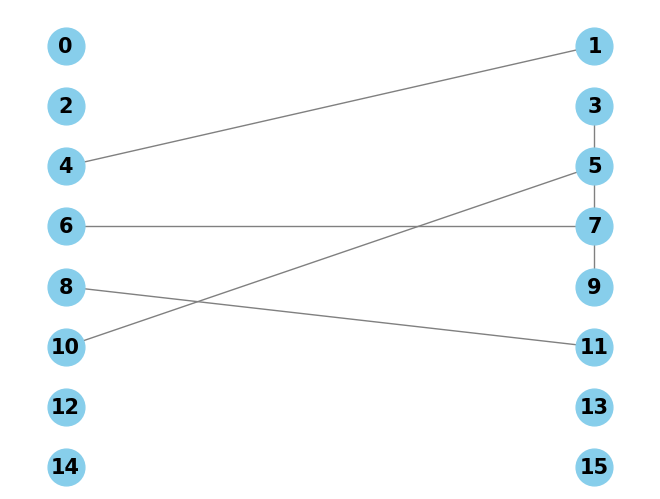

None

Simplified circuit: 


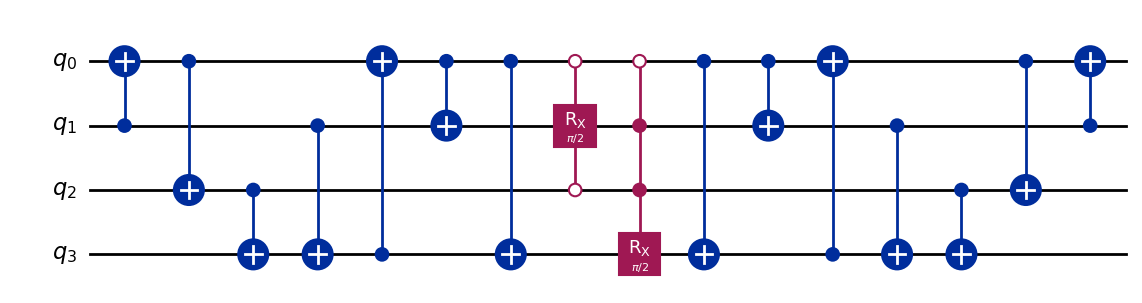

In [5]:

G = IntersectingEdgesGraph(edges)

big_qc = QuantumCircuit(G_tree.n_qubits)

for g in G.subgraphs:
    print(f'Edges: {g.edges}')
    display(g.draw())
    # print('Unsimplified circuit: ')
    # qc = g.get_qc(simplified=False)
    # display(qc.draw('mpl'))
    print('Simplified circuit: ')
    qc = g.get_qc(simplified=True)
    big_qc = big_qc.compose(qc)
    display(qc.draw('mpl'))
    

Full Circuit


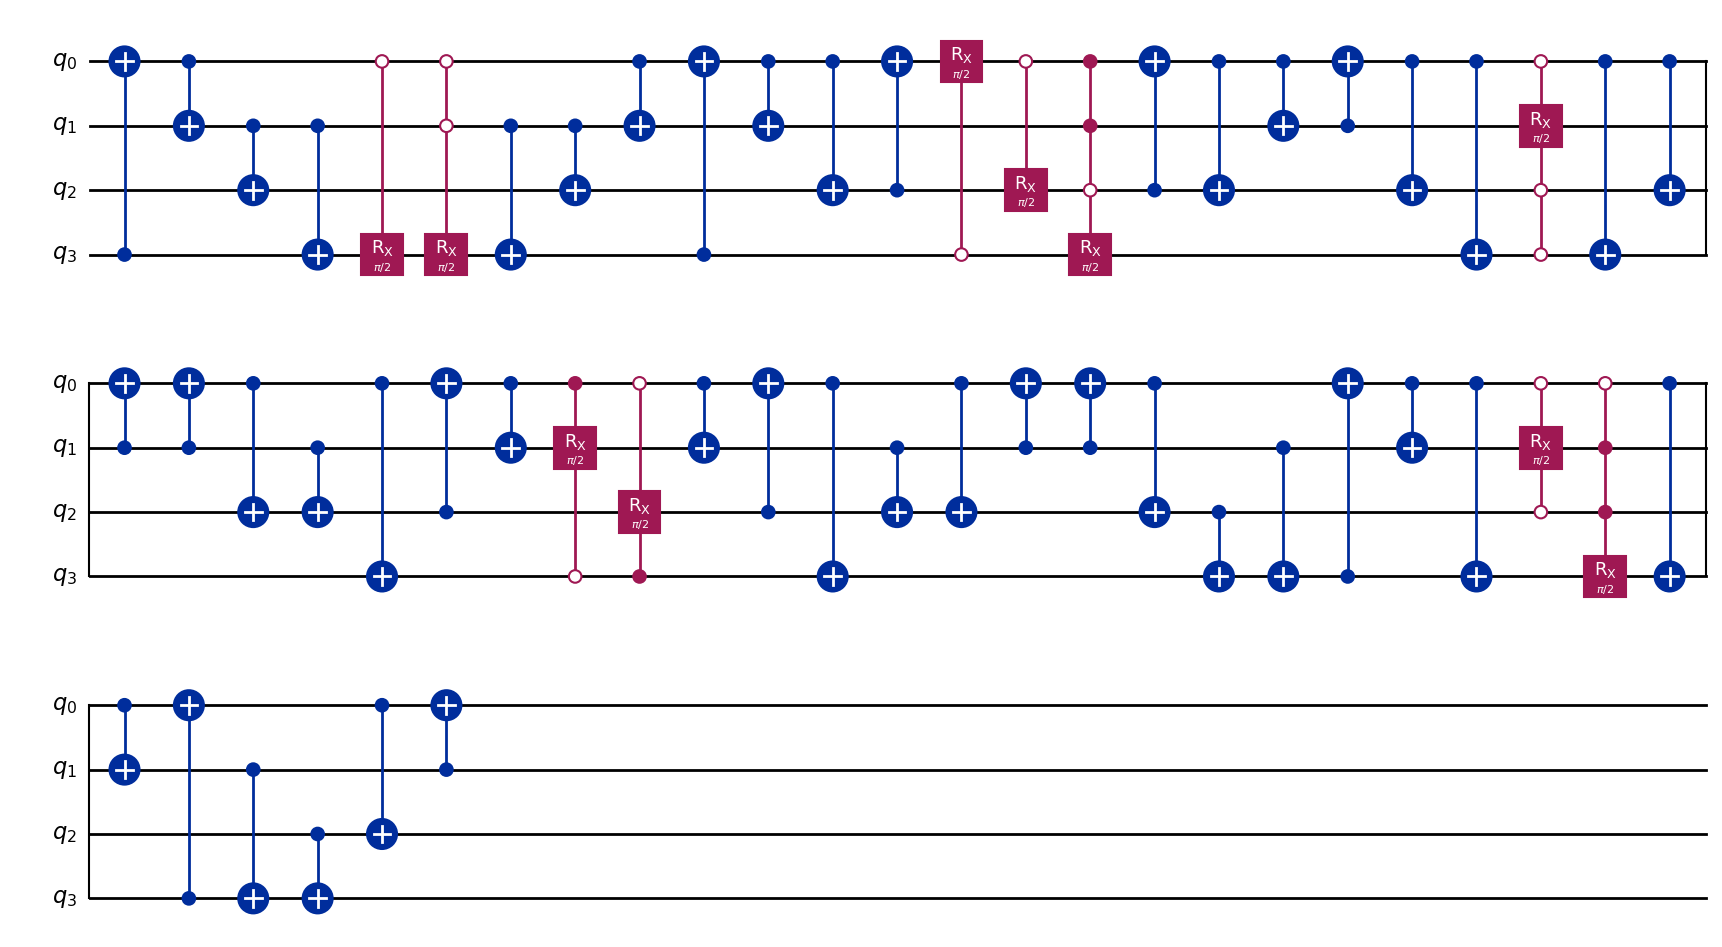

In [6]:
print('Full Circuit')
big_qc.draw('mpl')

In [7]:
from qiskit import transpile

transpiled_qc = transpile(
    big_qc,
    basis_gates=["cx", "u3"],
    optimization_level=3,
    seed_transpiler=12345
)

counts = transpiled_qc.count_ops()
print(f'Number of CX gates: {counts['cx']}')
print(f'Number of U3 gates: {counts['u3']}')

Number of CX gates: 134
Number of U3 gates: 101
